# Self Organizing Maps
___

In [1]:
#Library Import
import os
import torch
from pathlib import Path
from subprocess import call
import numpy as np
import cv2
import matplotlib.pyplot as plt
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader
from typing import List, Tuple
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans, AffinityPropagation, MeanShift, SpectralClustering, AgglomerativeClustering, DBSCAN
from sklearn.cluster import MeanShift, estimate_bandwidth
from sklearn.mixture import GaussianMixture
from sklearn.cluster import Birch
from sklearn.decomposition import PCA
import random
from PIL import Image
import pickle

#### Code

In [2]:
# Check if CUDA is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class ImageDataset(Dataset):
    def __init__(self, folder_path: str, transform=None):
        self.folder_path = folder_path
        self.image_files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        if transform is None:
            self.transform = transforms.Compose([
                transforms.Resize((224, 224)),
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                  std=[0.229, 0.224, 0.225])
            ])
        else:
            self.transform = transform
            
    def __len__(self):
        return len(self.image_files)
    
    def __getitem__(self, idx):
        img_path = os.path.join(self.folder_path, self.image_files[idx])
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, self.image_files[idx]

In [3]:
def extract_features(dataloader: DataLoader) -> np.ndarray:
    # Load the pre-trained ResNet-18 model
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    
    # Remove the last fully connected layer (for feature extraction)
    feature_extractor = torch.nn.Sequential(*list(model.children())[:-1])
    
    # Move the feature extractor to the GPU
    feature_extractor = feature_extractor.to(device)
    feature_extractor.eval()
    
    features = []
    
    with torch.no_grad():
        for batch, _ in dataloader:
            # Move the batch to the GPU
            batch = batch.to(device)
            
            # Extract features
            batch_features = feature_extractor(batch)
            
            # Flatten the features
            batch_features = batch_features.squeeze()
            
            # Convert to CPU and numpy array
            features.append(batch_features.cpu().numpy())
    
    return np.vstack(features)

In [4]:
class SOM:
    def __init__(self, input_dim: int, grid_size: Tuple[int, int], learning_rate: float = 0.1, radius: int = 1, device: torch.device = torch.device("cpu")):
        self.grid_size = grid_size
        self.input_dim = input_dim
        self.learning_rate = learning_rate
        self.radius = radius  # Use radius for updating nearest neighbors
        
        # Set the device
        self.device = device
        
        # Randomly initialize weights
        self.weights = np.random.randn(grid_size[0], grid_size[1], input_dim)
        self.weights = torch.tensor(self.weights, device=self.device)

    def find_bmu(self, x: torch.Tensor) -> Tuple[int, int]:
        """
        Find the Best Matching Unit (BMU)
        """
        x = x.to(self.device)  # Ensure x is on the same device as the weights
        distances = torch.sum((self.weights - x) ** 2, dim=2)
        distances = distances.cpu()  # Move the tensor to CPU before converting to NumPy
        return torch.unravel_index(torch.argmin(distances), distances.shape)

    def update_weights_kmeans(self, x: torch.Tensor, bmu: Tuple[int, int], lr: float):
        """
        Update weights of the BMU and its neighbors using K-means inspired update
        """
        for i in range(self.grid_size[0]):
            for j in range(self.grid_size[1]):
                # Compute distance from the BMU
                dist = (i - bmu[0]) ** 2 + (j - bmu[1]) ** 2
                if dist <= self.radius**2:  # Only update if within the neighborhood radius
                    # Update the weights of the BMU and its neighbors
                    self.weights[i, j] += lr * (x - self.weights[i, j])

    def train(self, data: np.ndarray, epochs: int = 100):
        data = torch.tensor(data, device=self.device)
        
        initial_radius = self.radius
        for epoch in range(epochs):
            lr = self.learning_rate * np.exp(-epoch / epochs)
            current_radius = initial_radius * np.exp(-epoch / epochs)  # Decay the radius
            
            for x in data:
                x = x.to(self.device)  # Ensure x is on the same device as weights
                bmu = self.find_bmu(x)
                self.update_weights_kmeans(x, bmu, lr)

            if (epoch + 1) % 10 == 0:
                print(f"Epoch {epoch + 1}/{epochs} completed")

In [5]:
def test_som(features: np.ndarray, sizes: List[Tuple[int, int]], epochs: int = 50):
    results = {}
    
    #Convert the input features to a tensor
    features = torch.tensor(features, dtype=torch.float32)

    for size in sizes:
        print(f"\nTesting SOM size {size}")
        
        # Create and train SOM with different sizes
        som = SOM(input_dim=features.shape[1], grid_size=size)
        som.train(features, epochs=epochs)
        
        # Calculate quantization error
        total_error = 0
        for x in features:
            x = x.to(som.weights.device)  # Ensure x is on the same device as weights
            bmu = som.find_bmu(x)
            error = np.sum((x.cpu().numpy() - som.weights[bmu].cpu().numpy()) ** 2)  # Move tensors to CPU before using NumPy
            total_error += error
        
        avg_error = total_error / len(features)
        results[size] = avg_error
        print(f"Average quantization error: {avg_error}")
    
    return results

In [6]:
def visualize_som_pca(som: SOM, training_data: np.ndarray, method: str = 'som_only') -> None:
    # Ensure training_data is on the same device as SOM weights
    device = som.device
    training_data = torch.tensor(training_data, device=device)
    
    # Initialize PCA
    pca = PCA(n_components=3)
    
    # Fit PCA on the appropriate data
    if method == 'full':
        # Fit PCA on entire training set
        pca.fit(training_data.cpu().numpy())  # Convert to CPU NumPy array for PCA
    else:
        # Fit PCA only on SOM weights
        weights_2d = som.weights.view(-1, som.input_dim).cpu().numpy()  # Flatten and move to CPU
        pca.fit(weights_2d)
    
    # Transform SOM weights
    weights_2d = som.weights.view(-1, som.input_dim).cpu().numpy()  # Flatten and move to CPU
    weights_3d = pca.transform(weights_2d)
    
    # Normalize to [0, 1] range for RGB color display
    weights_3d_normalized = (weights_3d - weights_3d.min(axis=0)) / (weights_3d.max(axis=0) - weights_3d.min(axis=0))
    
    # Create 3D plot
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # Plot each neuron
    for i in range(som.grid_size[0]):
        for j in range(som.grid_size[1]):
            idx = i * som.grid_size[1] + j
            color = weights_3d_normalized[idx]
            ax.scatter(weights_3d[idx, 0], 
                       weights_3d[idx, 1], 
                       weights_3d[idx, 2], 
                       c=[color], 
                       s=100)
    
    ax.set_title(f'SOM 3D PCA Visualization ({method} fitting)')
    plt.show()

In [78]:
def visualize_som_with_images(som: SOM, images: List[np.ndarray], features: np.ndarray) -> None:
    device = som.device
    images = [torch.tensor(image).to(device) for image in images]
    features = torch.tensor(features).to(device)

    cell_images = {}
    
    for idx, (feature, image) in enumerate(zip(features, images)):
        feature = torch.tensor(feature).to(device)
        
        bmu = som.find_bmu(feature)
        print(f"BMU for feature {idx}: {bmu}")  # Debug print
        distance = torch.sum((feature - som.weights[bmu]) ** 2).item()
        print(f"Distance for feature {idx}: {distance}")  # Debug print
        
        if bmu not in cell_images:
            cell_images[bmu] = []
        cell_images[bmu].append((image.cpu().numpy(), distance))

    print(f"Number of populated cells: {len(cell_images)}")  # Debug print
    for bmu, imgs in cell_images.items():
        print(f"Grid cell {bmu}: {len(imgs)} images")  # Debug print

    fig, axes = plt.subplots(som.grid_size[0], som.grid_size[1], figsize=(30, 30))
    for i in range(som.grid_size[0]):
        for j in range(som.grid_size[1]):
            if (i, j) in cell_images:
                best_image = min(cell_images[(i, j)], key=lambda x: x[1])[0]
                axes[i, j].imshow(best_image)
            axes[i, j].axis('off')
    
    plt.tight_layout()
    plt.show()

def visualize_activation_map(som: SOM, input_feature: np.ndarray) -> None:
    device = som.device
    input_feature = torch.tensor(input_feature).to(device)
    
    distances = np.zeros(som.grid_size)
    for i in range(som.grid_size[0]):
        for j in range(som.grid_size[1]):
            distances[i, j] = torch.sum((som.weights[i, j] - input_feature) ** 2).cpu().numpy()
    
    distances = (distances - distances.min()) / (distances.max() - distances.min())  # Normalize
    
    plt.figure(figsize=(30, 30))
    plt.imshow(distances, cmap='hot_r')
    plt.colorbar(label='Activation Strength')
    plt.title('SOM Activation Map')
    plt.show()

In [32]:
def create_image_grid(som: SOM, images: List[np.ndarray], features: np.ndarray) -> np.ndarray:
    """
    Creates a dictionary mapping SOM grid cells to best matching images.
    
    Parameters:
    som: trained SOM model
    images: list of images associated with features
    features: list of feature vectors corresponding to images
    
    Returns:
    Dictionary mapping grid cells to best matching images
    """
    # Ensure features are tensors on the correct device
    device = som.device
    features = torch.tensor(features).to(device)
    
    # Create dictionary to store images for each cell
    cell_images = {}
    
    # Find BMU for each image
    for idx, (feature, image) in enumerate(zip(features, images)):
        bmu = som.find_bmu(feature)
        if bmu not in cell_images:
            cell_images[bmu] = []
        cell_images[bmu].append(image)
    
    return cell_images

In [27]:
def visualize_som_with_images_and_empty_cells(som: SOM, images: List[np.ndarray], features: np.ndarray) -> None:
    # Create a dictionary to store best matching images for each cell
    cell_images = {}
    
    # Find BMU for each image
    for idx, (feature, image) in enumerate(zip(features, images)):
        bmu = som.find_bmu(feature)
        if bmu not in cell_images:
            cell_images[bmu] = []
        cell_images[bmu].append((image, np.sum((feature - som.weights[bmu]) ** 2)))
    
    # Create image grid
    fig, axes = plt.subplots(som.grid_size[0], som.grid_size[1], 
                            figsize=(20, 20))
    
    # Calculate distances between all units
    unit_distances = {}
    for i in range(som.grid_size[0]):
        for j in range(som.grid_size[1]):
            if (i, j) not in cell_images:
                
                # Calculate distances from this empty unit to all other units
                distances = []
                for ni in range(som.grid_size[0]):
                    for nj in range(som.grid_size[1]):
                        if (ni, nj) in cell_images:
                            dist = np.sum((som.weights[i, j] - som.weights[ni, nj]) ** 2)
                            distances.append(((ni, nj), dist))
                if distances:
                    # Find the closest non-empty unit
                    closest_unit = min(distances, key=lambda x: x[1])[0]
                    unit_distances[(i, j)] = closest_unit
    
    # Display images
    for i in range(som.grid_size[0]):
        for j in range(som.grid_size[1]):
            if (i, j) in cell_images:
                # Display best matching image for this unit
                best_image = min(cell_images[(i, j)], key=lambda x: x[1])[0]
                axes[i, j].imshow(best_image)
                axes[i, j].set_title(f'Original', fontsize=8)
            else:
                # Display image from closest non-empty unit
                if (i, j) in unit_distances:
                    closest_unit = unit_distances[(i, j)]
                    best_image = min(cell_images[closest_unit], key=lambda x: x[1])[0]
                    axes[i, j].imshow(best_image, alpha=0.5)  # Use transparency
                    axes[i, j].set_title(f'Closest to {closest_unit}', fontsize=8)
            
            axes[i, j].axis('off')
    
    plt.tight_layout()
    plt.show()

In [72]:
def plot_pottery_som(lattice, figsize=(30, 30)):
    # Create a figure and axes
    x = lattice.weights.shape[0]  # Grid size in the x direction
    y = lattice.weights.shape[1]  # Grid size in the y direction
    fig, axs = plt.subplots(x, y, figsize=figsize)
    
    # Iterate over the grid
    for col in range(x):
        for row in range(y):
            # Access the weight vector at this grid position
            weight_vector = lattice.weights[col, row]
            
            # Reshape the weight vector into an image (adjust this based on your image's dimensions)
            # Assuming 512 values per weight vector corresponds to a 16x32 image (grayscale)
            image_shape = (16, 32)  # Adjust this if your image dimensions are different
            image = weight_vector.reshape(image_shape)
            
            # Plot the image in the corresponding subplot
            axs[row, col].imshow(image, cmap='gray')
            axs[row, col].axis('off')  # Hide axes
    
    # Adjust spacing between subplots
    plt.tight_layout()
    plt.show()

In [9]:
#Save and Load to Pickle
def save_som_train(som: SOM, filepath: str) -> None:
    with open(filepath, 'wb') as f:
        pickle.dump({
            'weights': som.weights,
            'grid_size': som.grid_size,
            'input_dim': som.input_dim,
            'learning_rate': som.learning_rate
        }, f)
    print(f"Model saved to: {filepath}")

def load_som_file(filepath: str) -> SOM:
    with open(filepath, 'rb') as f:
        data = pickle.load(f)
    # Create new SOM instance
    som = SOM(input_dim=data['input_dim'], 
              grid_size=data['grid_size'], 
              learning_rate=data['learning_rate'])
    som.weights = data['weights']
    
    return som

#### Execute

In [10]:
#Variable
dataset = ImageDataset(r"E:\OneDrive\Documents\007-Study Life\001-Urban Design\RC11_Thesis_Project\Datasets\Antiques\Antiques")
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.2102921..1.6116778].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0494049..1.7522904].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.3879551..2.3088455].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7240347..2.343704].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8781574..2.64].


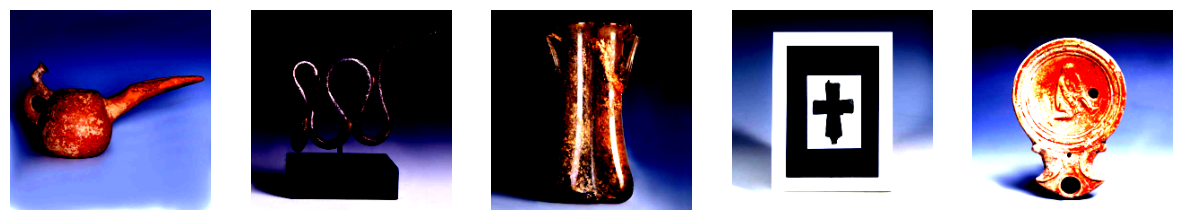

In [11]:
# Show some sample images
plt.figure(figsize=(15, 5))
for i, (images, labels) in enumerate(dataloader):  # Iterate over the dataloader
    if i == 1:  # Only show one batch (you can adjust this number)
        for j in range(5):
            plt.subplot(1, 5, j+1)
            plt.imshow(images[j].permute(1, 2, 0).numpy())  # Convert tensor to numpy array for plotting
            plt.axis('off')
        break  # Exit the loop after showing the first batch

plt.show()

In [13]:
#Extract features for all images
image_features = extract_features(dataloader)
print(f"Extracted features shape: {image_features.shape}")

Extracted features shape: (991, 512)


In [14]:
#SOM Training
som = SOM(input_dim=image_features.shape[1], grid_size=(30, 30))
som.train(image_features)

Epoch 10/100 completed
Epoch 20/100 completed
Epoch 30/100 completed
Epoch 40/100 completed
Epoch 50/100 completed
Epoch 60/100 completed
Epoch 70/100 completed
Epoch 80/100 completed
Epoch 90/100 completed
Epoch 100/100 completed



Testing SOM size (5, 5)


C:\Users\Patrick\AppData\Local\Temp\ipykernel_40840\118867028.py:37: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data = torch.tensor(data, device=self.device)


Epoch 10/50 completed
Epoch 20/50 completed
Epoch 30/50 completed
Epoch 40/50 completed
Epoch 50/50 completed
Average quantization error: 252.7959377544295

Testing SOM size (10, 10)
Epoch 10/50 completed
Epoch 20/50 completed
Epoch 30/50 completed
Epoch 40/50 completed
Epoch 50/50 completed
Average quantization error: 205.60620994957677

Testing SOM size (15, 15)
Epoch 10/50 completed
Epoch 20/50 completed
Epoch 30/50 completed
Epoch 40/50 completed
Epoch 50/50 completed
Average quantization error: 184.24743600133664


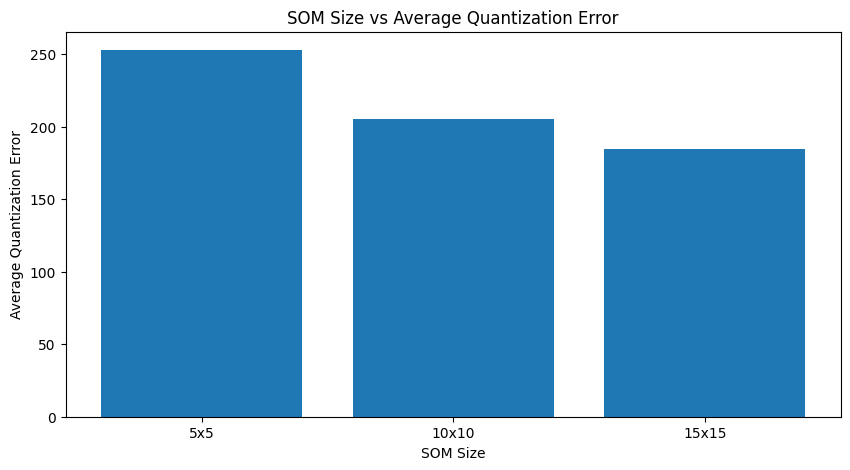

In [15]:
#Test different SOM sizes
test_sizes = [(5, 5), (10, 10), (15, 15)]
size_results = test_som(image_features, test_sizes)

#Plot results
plt.figure(figsize=(10, 5))
plt.bar([f"{s[0]}x{s[1]}" for s in size_results.keys()], list(size_results.values()))
plt.title('SOM Size vs Average Quantization Error')
plt.xlabel('SOM Size')
plt.ylabel('Average Quantization Error')
plt.show()

In [18]:
#Variable
save_path = os.path.join("Pickle","trained_som.pkl")
#Save Trained SOM
save_som_train(som, save_path)

Model saved to: Pickle\trained_som.pkl


In [37]:
# Load the SOM model from the saved file
loaded_som = load_som_file(save_path)

# Ensure that your input is a torch tensor
test_input = torch.tensor(image_features[0], dtype=torch.float32)

# Ensure the tensor is on the same device as the model's weights
test_input = test_input.to(loaded_som.device)

# Find the Best Matching Unit (BMU) for the original model
original_bmu = som.find_bmu(test_input)

# Find the Best Matching Unit (BMU) for the loaded model
loaded_bmu = loaded_som.find_bmu(test_input)

# Output the results
print("Original model BMU:", original_bmu)
print("Loaded model BMU:", loaded_bmu)
print("BMU match:", original_bmu == loaded_bmu)

Original model BMU: (tensor(20), tensor(11))
Loaded model BMU: (tensor(20), tensor(11))
BMU match: True


In [38]:
print("Original model weights shape:", som.weights.shape)
print("Loaded model weights shape:", loaded_som.weights.shape)


Original model weights shape: torch.Size([30, 30, 512])
Loaded model weights shape: torch.Size([30, 30, 512])


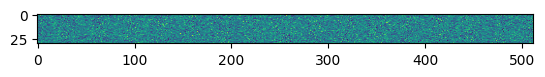

In [45]:
# Display image associated with BMU of the loaded model
plt.imshow(loaded_som.weights[29])  
plt.show()

In [56]:
loaded_som.weights[0]

tensor([[-0.4078,  0.2053, -0.2669,  ...,  1.5321,  0.1347, -1.0303],
        [ 0.3284,  1.5119,  0.9717,  ...,  0.5901,  0.2896, -1.0005],
        [ 0.4646, -0.4088, -0.9644,  ...,  1.0518, -0.0566,  0.6537],
        ...,
        [-0.4232,  0.5772,  0.5451,  ..., -1.2923,  0.1329, -0.4864],
        [-0.4360, -0.6909,  0.9651,  ...,  0.4537, -1.4677, -0.6184],
        [-0.5600, -0.5079,  0.1851,  ..., -1.0060,  1.0317,  0.8669]],
       dtype=torch.float64)

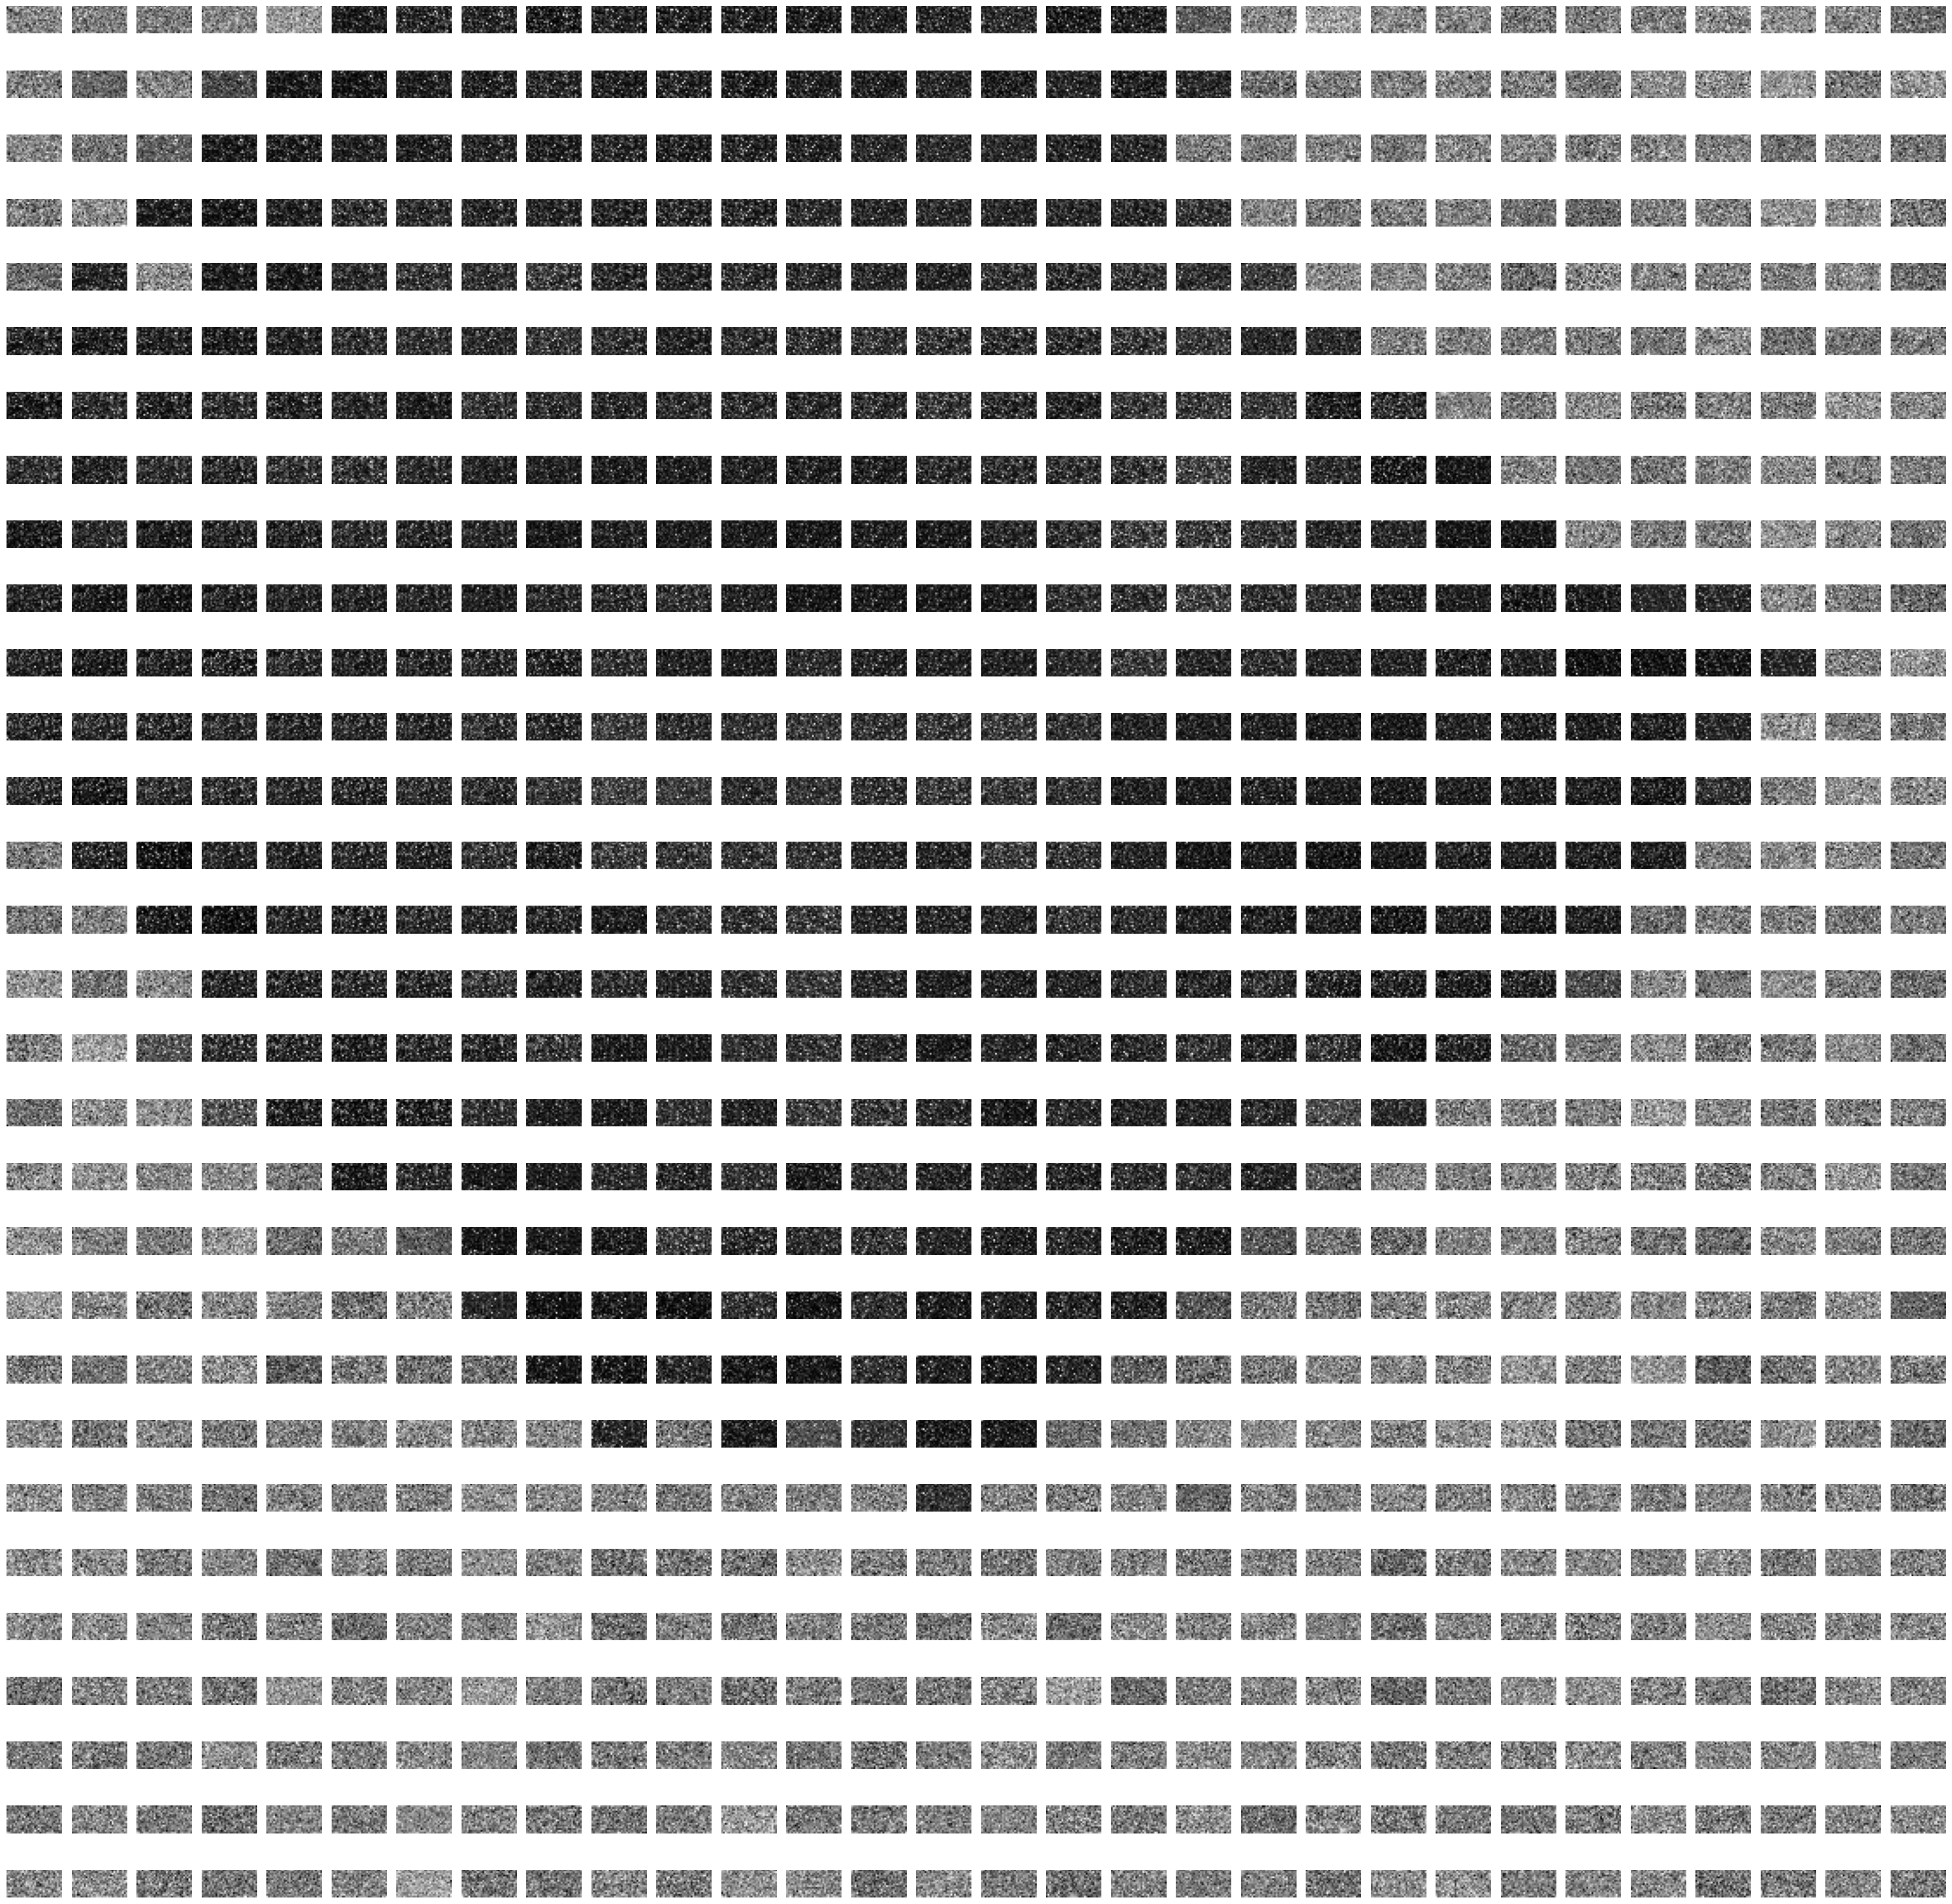

In [71]:
plot_pottery_som(loaded_som)

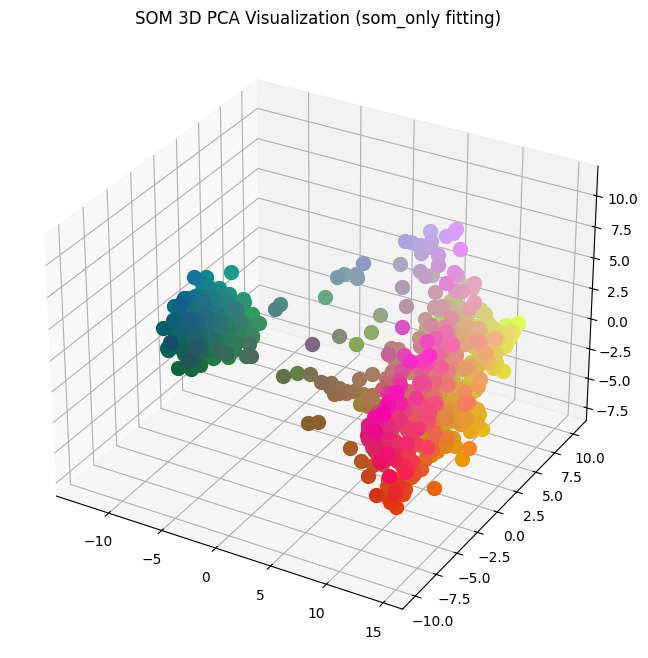

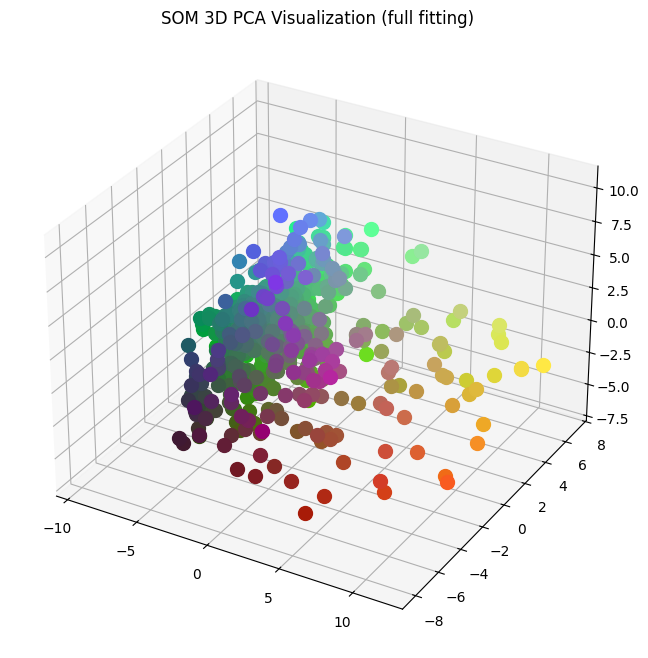

In [24]:
#Test both PCA methods
visualize_som_pca(som, image_features, method='som_only')
visualize_som_pca(som, image_features, method='full')

Displaying SOM image mapping:
BMU for feature 0: (tensor(20), tensor(11))
Distance for feature 0: 111.88614312245016
BMU for feature 1: (tensor(12), tensor(9))
Distance for feature 1: 121.57255346910486
BMU for feature 2: (tensor(20), tensor(11))
Distance for feature 2: 103.29603177941567
BMU for feature 3: (tensor(6), tensor(8))
Distance for feature 3: 127.52580637788442
BMU for feature 4: (tensor(7), tensor(3))
Distance for feature 4: 112.3806530436465
BMU for feature 5: (tensor(19), tensor(12))
Distance for feature 5: 138.68962413214192
BMU for feature 6: (tensor(20), tensor(13))
Distance for feature 6: 66.7599152805738
BMU for feature 7: (tensor(14), tensor(4))
Distance for feature 7: 254.85481678963748
BMU for feature 8: (tensor(15), tensor(1))
Distance for feature 8: 0.07304547600120873
BMU for feature 9: (tensor(13), tensor(7))
Distance for feature 9: 149.0400217139025
BMU for feature 10: (tensor(13), tensor(15))
Distance for feature 10: 283.7088546637088
BMU for feature 11: (te

C:\Users\Patrick\AppData\Local\Temp\ipykernel_40840\1979119168.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  feature = torch.tensor(feature).to(device)


BMU for feature 307: (tensor(13), tensor(12))
Distance for feature 307: 129.96876902531795
BMU for feature 308: (tensor(10), tensor(1))
Distance for feature 308: 94.86277989303312
BMU for feature 309: (tensor(8), tensor(8))
Distance for feature 309: 130.96049455167662
BMU for feature 310: (tensor(14), tensor(2))
Distance for feature 310: 205.31900078946268
BMU for feature 311: (tensor(17), tensor(5))
Distance for feature 311: 149.43991083275887
BMU for feature 312: (tensor(1), tensor(7))
Distance for feature 312: 108.59187249201081
BMU for feature 313: (tensor(14), tensor(4))
Distance for feature 313: 122.57256693050235
BMU for feature 314: (tensor(9), tensor(14))
Distance for feature 314: 295.4733312892368
BMU for feature 315: (tensor(9), tensor(12))
Distance for feature 315: 151.98101677673873
BMU for feature 316: (tensor(17), tensor(7))
Distance for feature 316: 317.24989104596597
BMU for feature 317: (tensor(5), tensor(3))
Distance for feature 317: 113.14164007807598
BMU for featur

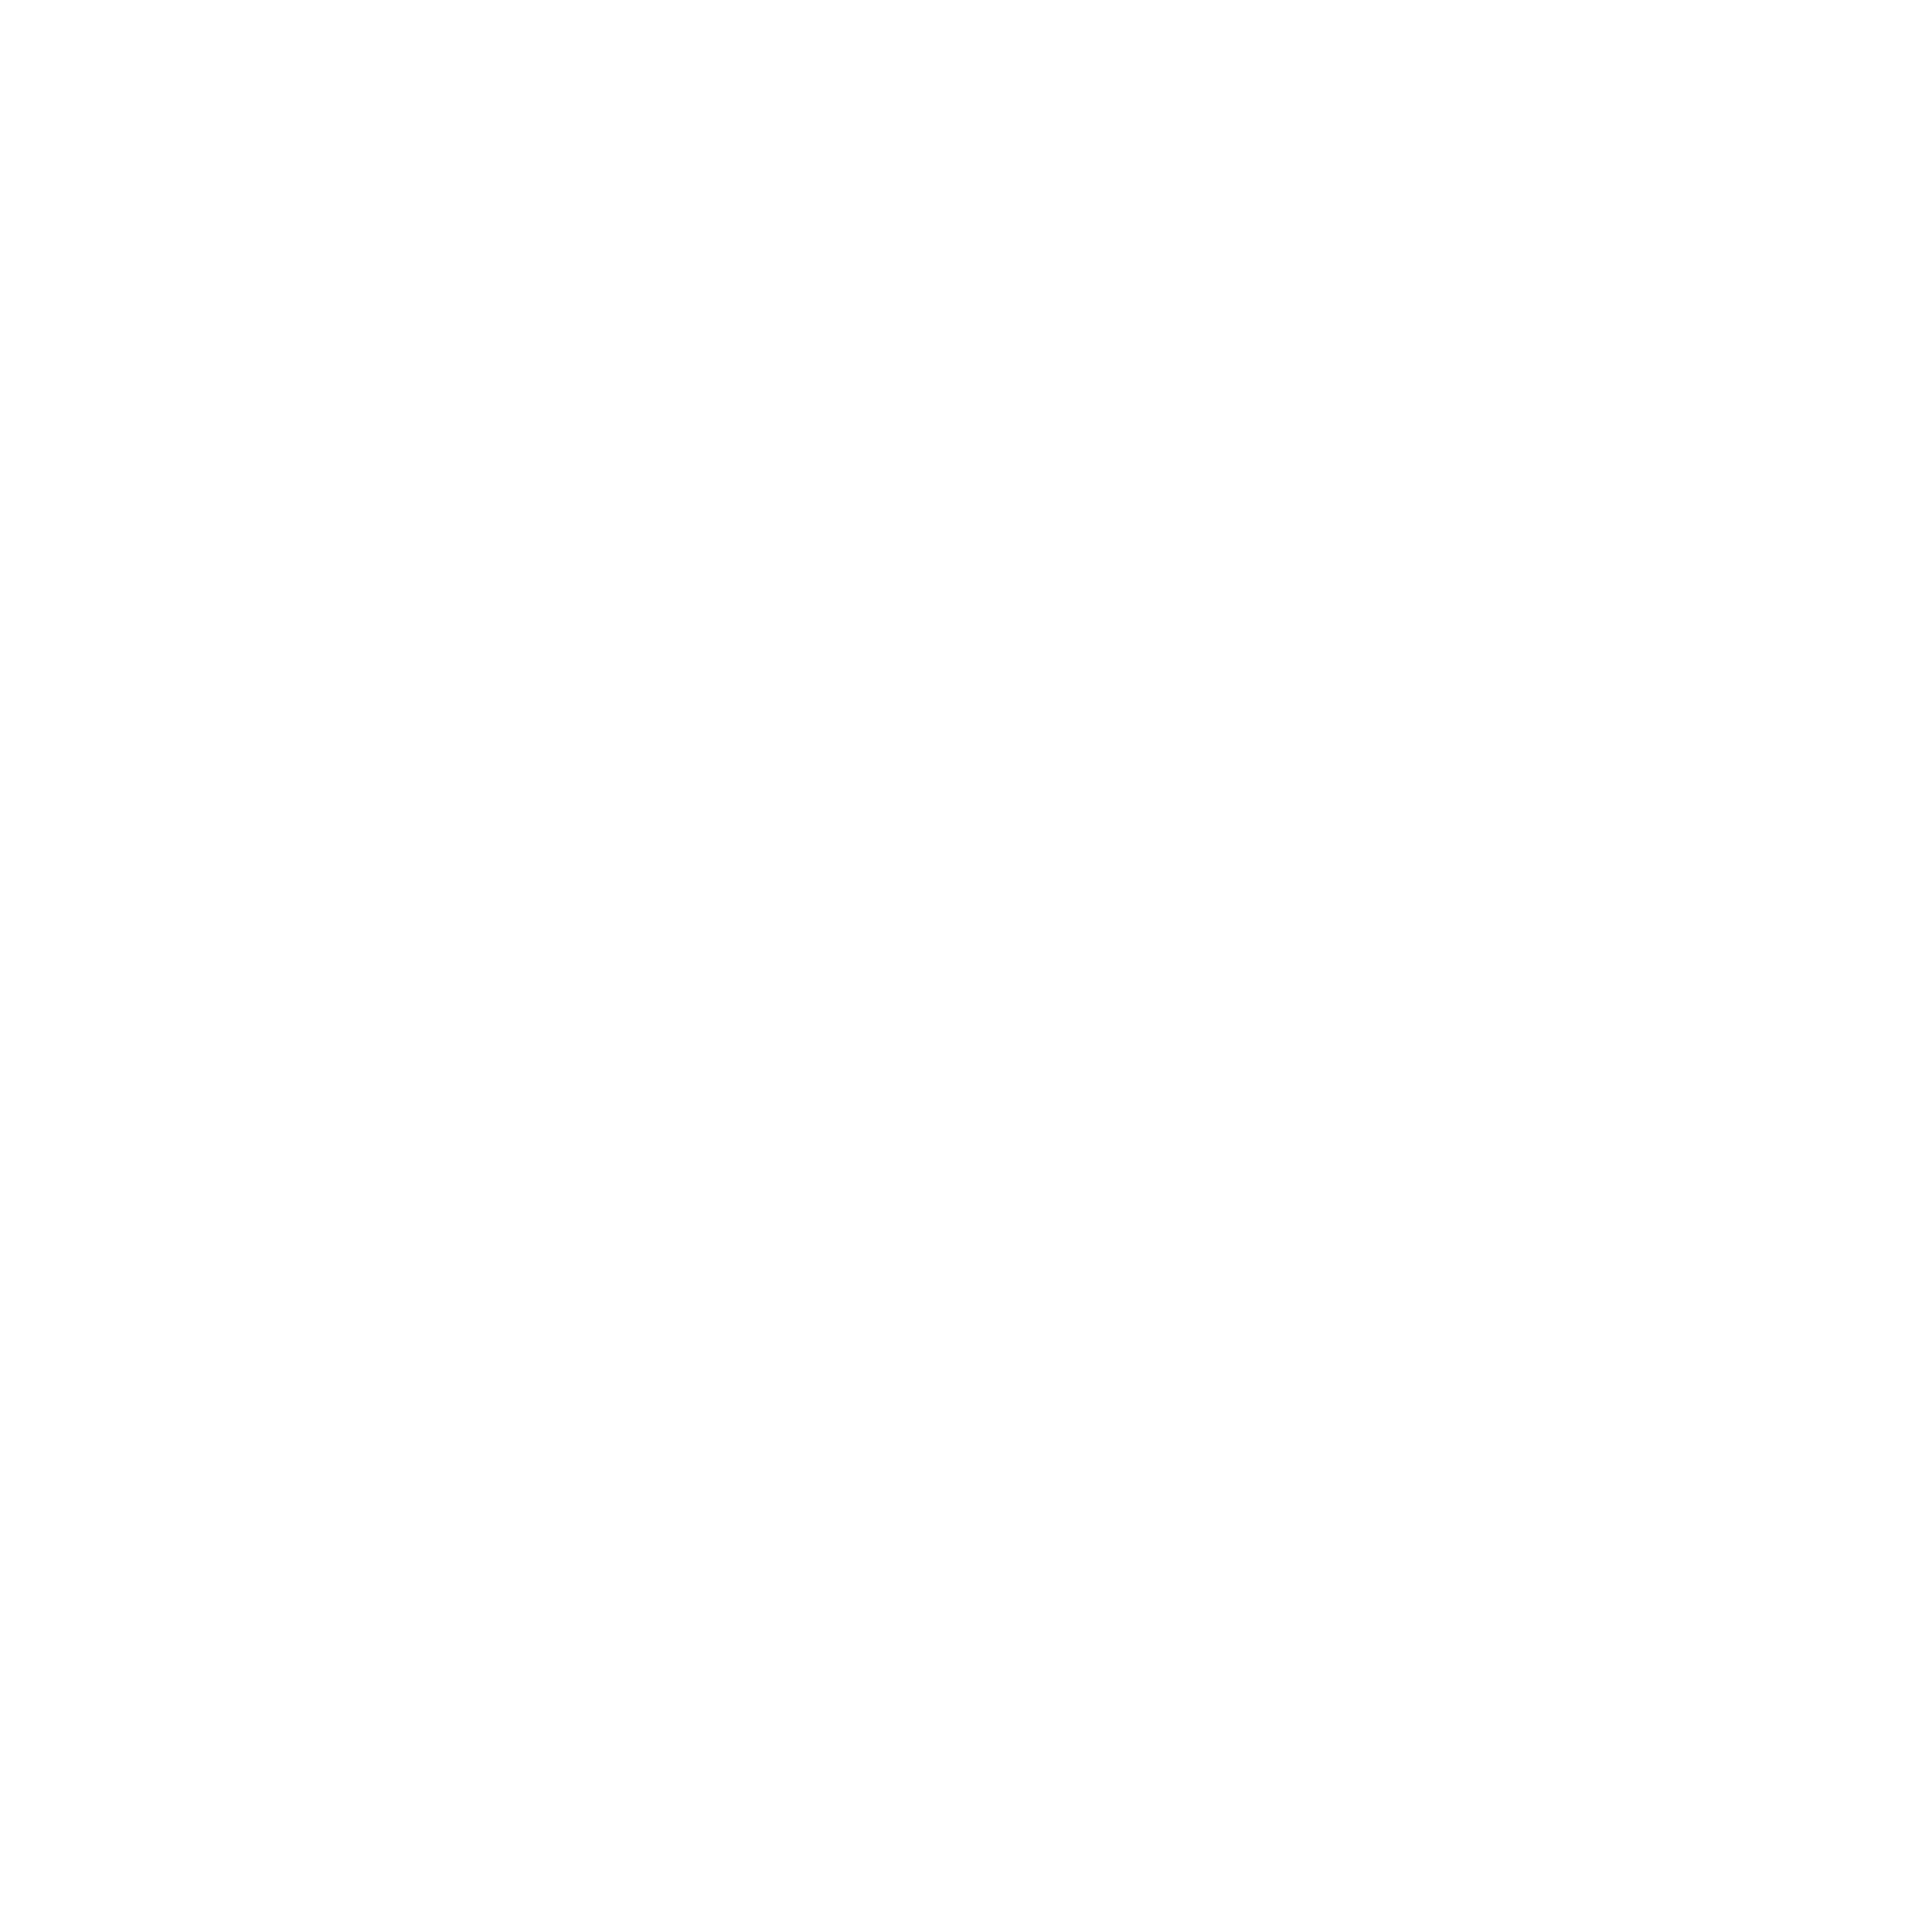

Displaying sample activation map:


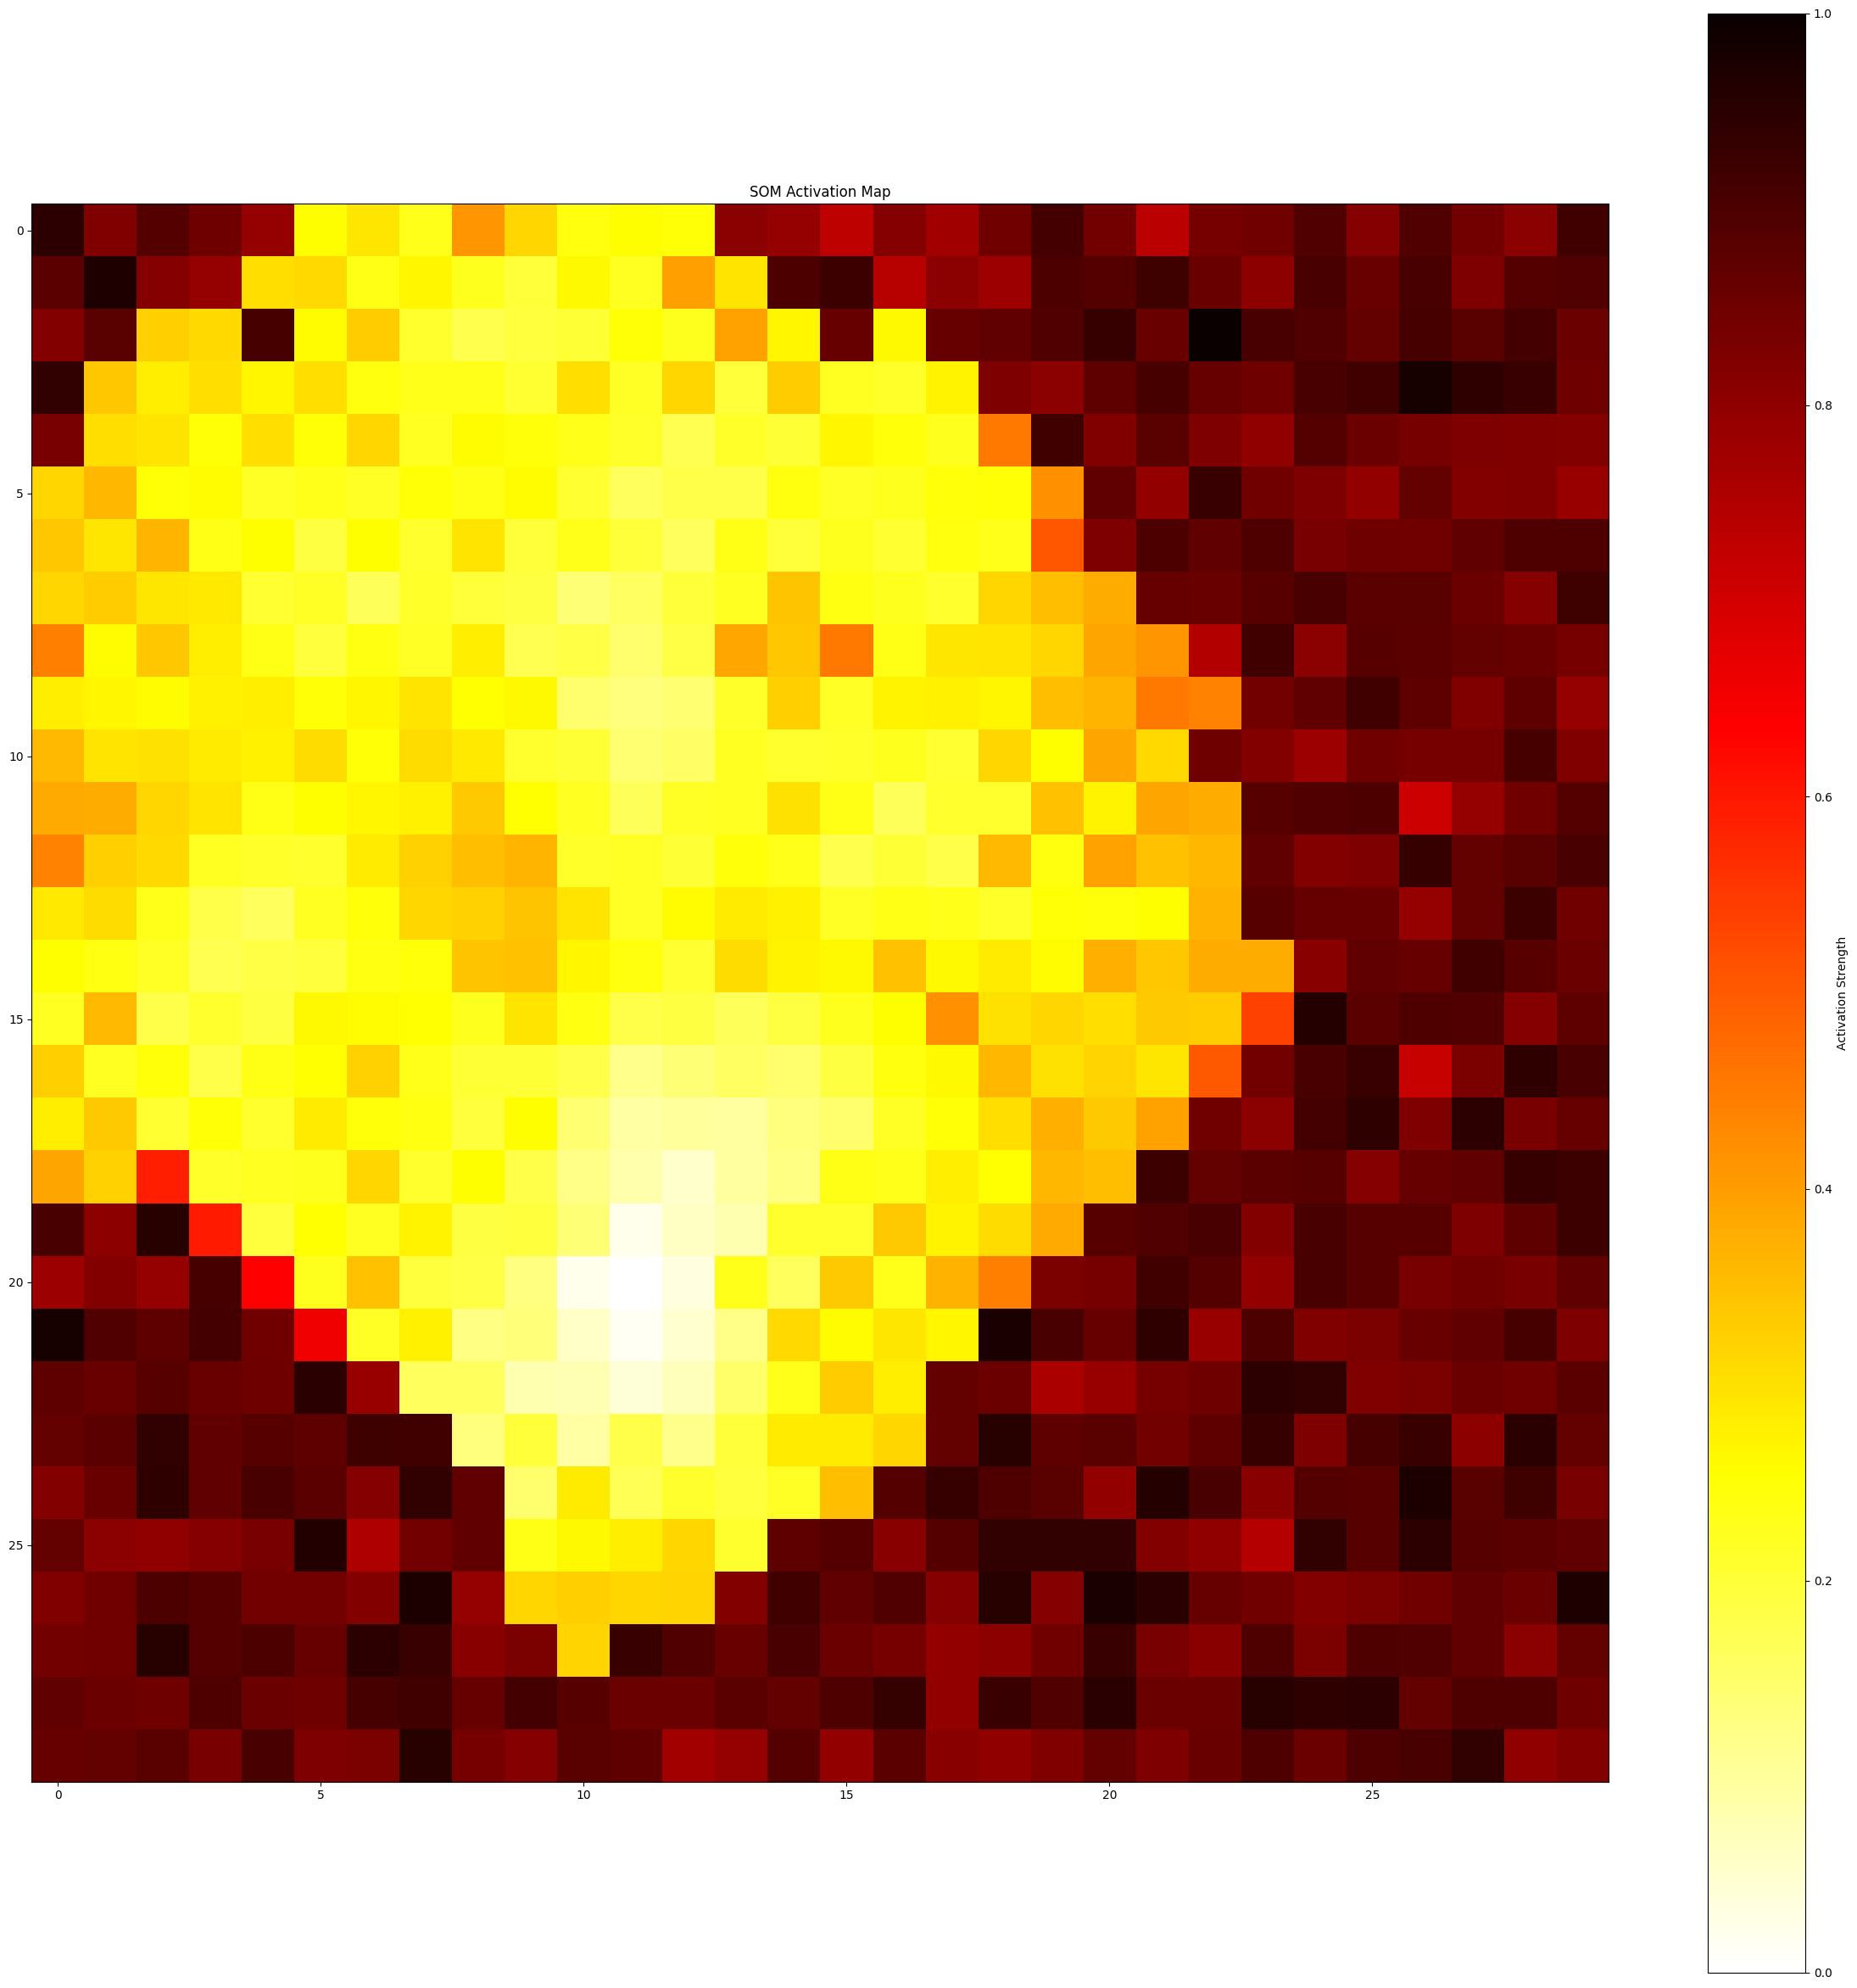

Creating image grid:
Distribution of images in each cell:
Position (tensor(20), tensor(11)): 1 images
Position (tensor(12), tensor(9)): 1 images
Position (tensor(20), tensor(11)): 1 images
Position (tensor(6), tensor(8)): 1 images
Position (tensor(7), tensor(3)): 1 images
Position (tensor(19), tensor(12)): 1 images
Position (tensor(20), tensor(13)): 1 images
Position (tensor(14), tensor(4)): 1 images
Position (tensor(15), tensor(1)): 1 images
Position (tensor(13), tensor(7)): 1 images
Position (tensor(13), tensor(15)): 1 images
Position (tensor(11), tensor(10)): 1 images
Position (tensor(13), tensor(3)): 1 images
Position (tensor(6), tensor(4)): 1 images
Position (tensor(18), tensor(10)): 1 images
Position (tensor(20), tensor(13)): 1 images
Position (tensor(3), tensor(16)): 1 images
Position (tensor(6), tensor(6)): 1 images
Position (tensor(11), tensor(4)): 1 images
Position (tensor(10), tensor(5)): 1 images
Position (tensor(9), tensor(1)): 1 images
Position (tensor(8), tensor(7)): 1 i

In [79]:
# Test these functions
original_images = []
for batch, _ in dataloader:
    for img in batch:
        # De-normalize images
        img = img * torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1) + \
              torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        original_images.append(img.permute(1, 2, 0).numpy())

# Display SOM with images
print("Displaying SOM image mapping:")
visualize_som_with_images(som, original_images, image_features)

# Display sample activation map
print("Displaying sample activation map:")
sample_feature = image_features[0]
visualize_activation_map(som, sample_feature)

# Create complete image grid
print("Creating image grid:")
image_grid = create_image_grid(som, original_images, image_features)

# Print number of images in each cell
print("Distribution of images in each cell:")
for pos, images in image_grid.items():
    print(f"Position {pos}: {len(images)} images")

C:\Users\Patrick\AppData\Local\Temp\ipykernel_40840\1979119168.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  feature = torch.tensor(feature).to(device)


BMU for feature 0: (tensor(20), tensor(11))
Distance for feature 0: 111.88614312245016
BMU for feature 1: (tensor(12), tensor(9))
Distance for feature 1: 121.57255346910486
BMU for feature 2: (tensor(20), tensor(11))
Distance for feature 2: 103.29603177941567
BMU for feature 3: (tensor(6), tensor(8))
Distance for feature 3: 127.52580637788442
BMU for feature 4: (tensor(7), tensor(3))
Distance for feature 4: 112.3806530436465
BMU for feature 5: (tensor(19), tensor(12))
Distance for feature 5: 138.68962413214192
BMU for feature 6: (tensor(20), tensor(13))
Distance for feature 6: 66.7599152805738
BMU for feature 7: (tensor(14), tensor(4))
Distance for feature 7: 254.85481678963748
BMU for feature 8: (tensor(15), tensor(1))
Distance for feature 8: 0.07304547600120873
BMU for feature 9: (tensor(13), tensor(7))
Distance for feature 9: 149.0400217139025
BMU for feature 10: (tensor(13), tensor(15))
Distance for feature 10: 283.7088546637088
BMU for feature 11: (tensor(11), tensor(10))
Distance

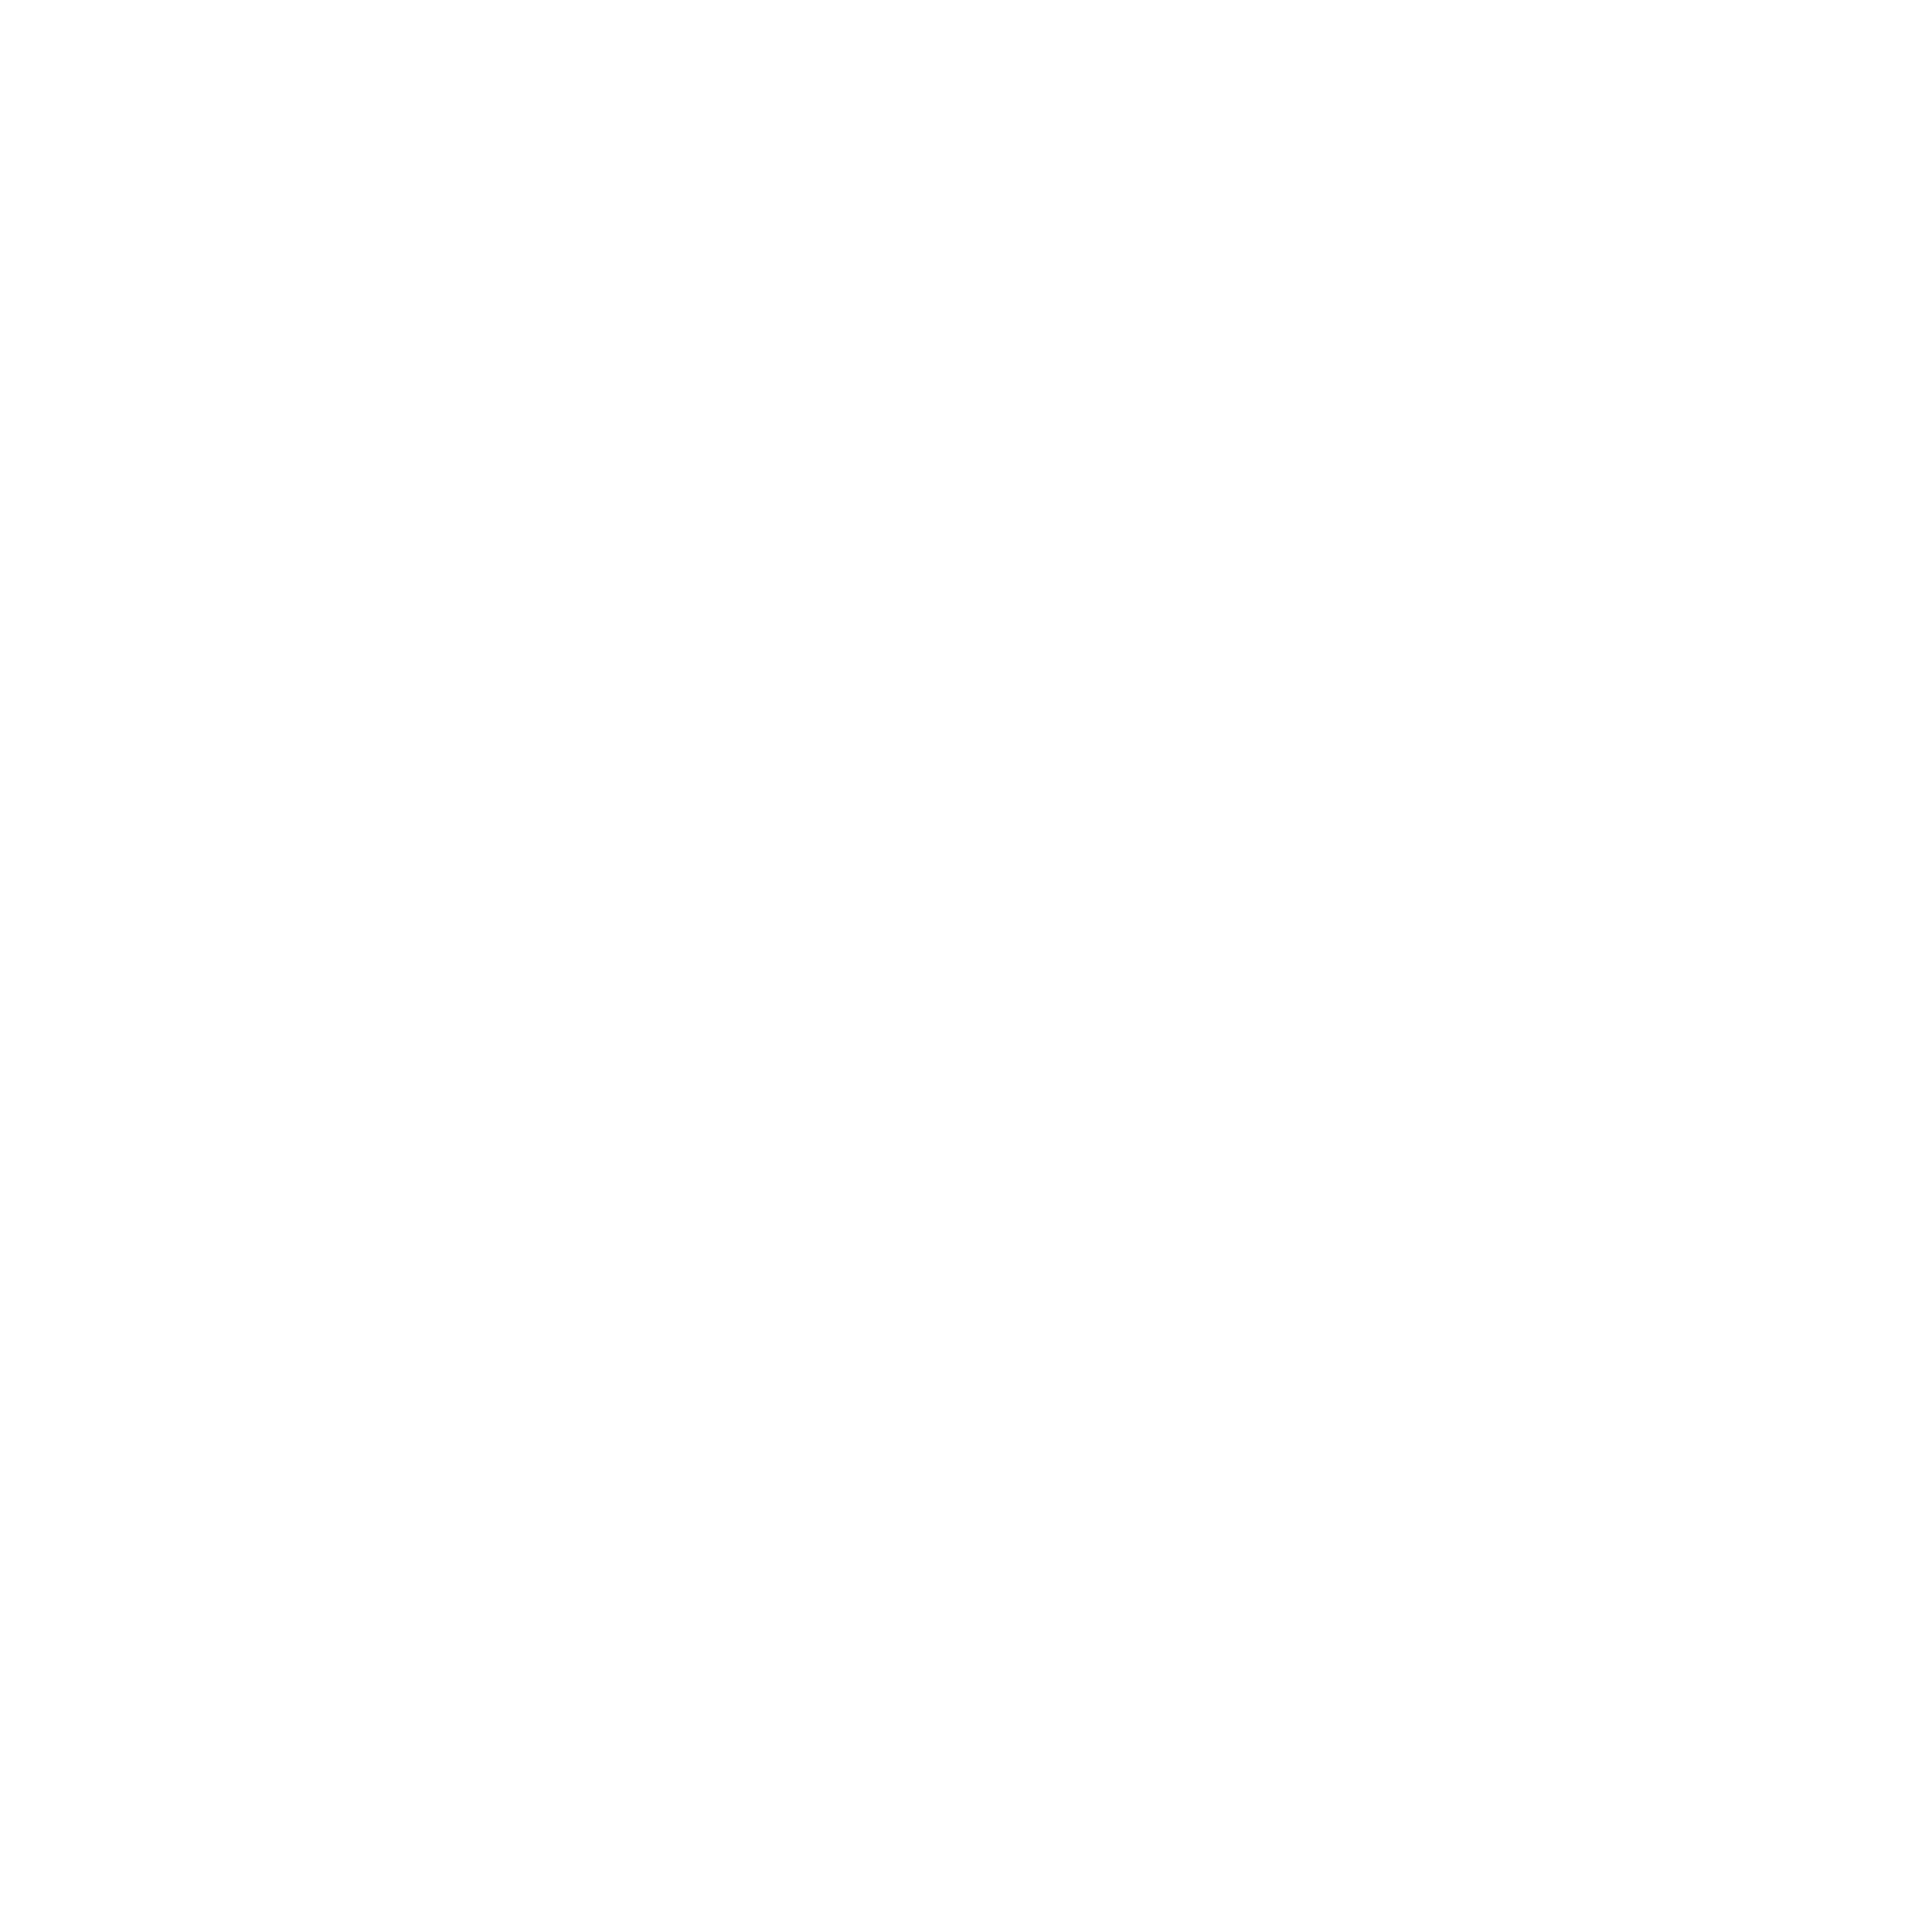

In [80]:
visualize_som_with_images(som, original_images, image_features)